# Explore EuroSAT with PyTorch

This notebook introduces the dataset, tensors, data loaders, and one optimization step. Run it from the `terraclass` project directory after `python -m pip install -e .`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import EuroSAT

from terraclass.data import TransformSubset, build_transforms, stratified_split_indices
from terraclass.models import build_model

torch.manual_seed(42)
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch: 2.13.0+cu126
CUDA available: True


## Download and inspect the raw dataset

TorchVision returns each raw sample as a PIL image and an integer class index. The first run downloads EuroSAT into the ignored `data/` directory.

In [2]:
dataset = EuroSAT(root=Path("data"), download=True)
image, label = dataset[0]

print(f"Examples: {len(dataset):,}")
print(f"Classes: {dataset.classes}")
print(f"Raw image type: {type(image).__name__}, size: {image.size}")
print(f"First label: {label} ({dataset.classes[label]})")

Examples: 27,000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Raw image type: Image, size: (64, 64)
First label: 0 (AnnualCrop)


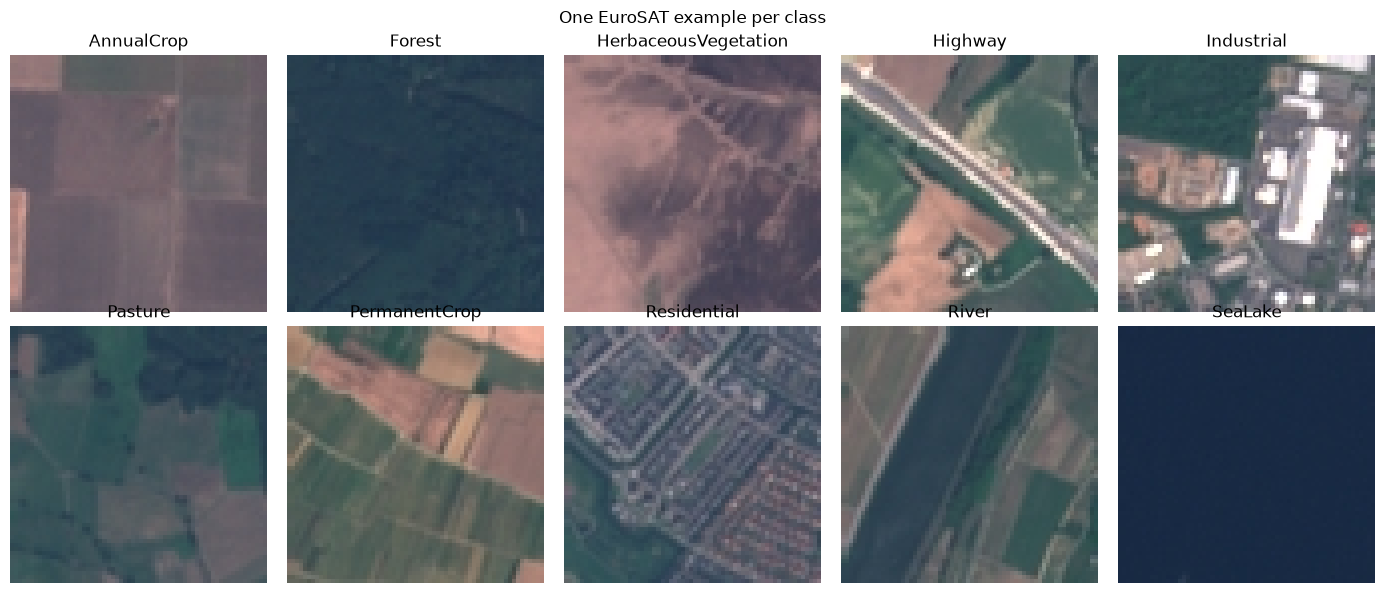

In [3]:
figure, axes = plt.subplots(2, 5, figsize=(14, 6))
for class_index, axis in enumerate(axes.flat):
    example_index = dataset.targets.index(class_index)
    example, _ = dataset[example_index]
    axis.imshow(example)
    axis.set_title(dataset.classes[class_index])
    axis.axis("off")
figure.suptitle("One EuroSAT example per class")
figure.tight_layout()

## Build a reproducible training batch

The split is stratified, so each class contributes the same proportion of its examples to train, validation, and test sets. Training transforms randomly augment images; evaluation transforms are deterministic.

In [4]:
train_indices, val_indices, test_indices = stratified_split_indices(dataset.targets, seed=42)
train_transform, _ = build_transforms(image_size=64)
train_dataset = TransformSubset(dataset, train_indices, train_transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

images, labels = next(iter(train_loader))
print(f"Split sizes: {len(train_indices):,} / {len(val_indices):,} / {len(test_indices):,}")
print(f"Image batch shape: {tuple(images.shape)}")
print(f"Label batch shape: {tuple(labels.shape)}")
print(f"Tensor dtype: {images.dtype}")

Split sizes: 18,900 / 4,050 / 4,050
Image batch shape: (8, 3, 64, 64)
Label batch shape: (8,)
Tensor dtype: torch.float32


A batch uses the `[batch, channels, height, width]` layout. The labels are integer indices because `CrossEntropyLoss` expects one target class per image.

## Run one optimization step

This is the heart of supervised learning in PyTorch: forward pass, loss, backward pass, and parameter update.

In [ ]:
model = build_model("cnn", num_classes=len(dataset.classes), pretrained=False)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

optimizer.zero_grad(set_to_none=True)
logits = model(images)
loss = criterion(logits, labels)
loss.backward()
optimizer.step()

print(f"Logit shape: {tuple(logits.shape)}")
print(f"Loss before this update: {loss.item():.4f}")
print(f"First convolution gradient norm: {model.features[0].weight.grad.norm().item():.4f}")

The nonzero gradient demonstrates that autograd connected the loss back to the first convolution. The CLI repeats this process for every batch, evaluates after each epoch, and saves the best checkpoint. Continue with `terraclass train --model cnn --epochs 1 --output-dir outputs/smoke-test`.